# N-Step DQN
이 튜토리얼은 **N-step DQN**을 구현하는 방법을 안내한다.

**N-step DQN**은 기본 DQN이 한 번의 행동(1-step) 후에 얻는 보상만을 사용하여 학습하는 것과 달리, **N번의 스텝 동안 얻은 보상의 합**을 사용하여 학습하는 방법이다. 이를 통해 더 먼 미래의 보상을 빠르게 전파할 수 있으며, 편향(Bias)과 분산(Variance) 사이의 균형을 조절하여 학습 속도와 안정성을 높일 수 있다.

이 튜토리얼은 **Rainbow DQN**의 구성 요소인 **Dueling Network**, **NoisyNet**, **PER (Prioritized Experience Replay)**, **N-step Learning**을 모두 포함하고 있다. 환경은 안정적인 학습과 실행을 위해 `LunarLander-v2`를 사용한다.

### 1. 가상 디스플레이 설정 (Setup virtual display)

강화학습 환경의 렌더링을 위해 가상 디스플레이를 설정한다.

In [ ]:
# 최신 파이썬 라이브러리 설치
%pip install gymnasium[box2d] pyvirtualdisplay torch numpy matplotlib imageio

In [1]:
from pyvirtualdisplay import Display

# 가상 디스플레이 시작
virtual_display = Display(visible=False, size=(1400, 900))
virtual_display.start()

### 2. 라이브러리 임포트 (Import libraries)

학습에 필요한 라이브러리를 불러온다.

In [2]:
import copy
import random
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from collections import deque
import gymnasium as gym
import matplotlib.pyplot as plt
from IPython.display import HTML
from base64 import b64encode
import imageio

# GPU 사용 가능 여부 확인
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 장치: {device}")

사용 장치: cuda


### 3. 비디오 출력 함수 (Display Video)

학습 결과를 영상으로 확인하기 위한 함수다.

In [3]:
def display_video(video_path):
    """
    저장된 mp4 비디오 파일을 읽어 HTML 태그로 변환하여 출력한다.
    """
    mp4 = open(video_path, 'rb').read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
    return HTML("""
    <video width=400 controls>
          <source src="%s" type="video/mp4">
    </video>
    """ % data_url)

### 4. Noisy Linear Layer 구현 (Implement Noisy Linear)

탐험을 위해 가중치에 노이즈를 추가하는 선형층을 정의한다.

In [4]:
class NoisyLinear(nn.Module):
    def __init__(self, in_features, out_features, std_init=0.5):
        """
        Noisy Linear Layer 초기화
        """
        super(NoisyLinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.std_init = std_init

        self.weight_mu = nn.Parameter(torch.empty(out_features, in_features))
        self.weight_sigma = nn.Parameter(torch.empty(out_features, in_features))
        self.register_buffer('weight_epsilon', torch.empty(out_features, in_features))

        self.bias_mu = nn.Parameter(torch.empty(out_features))
        self.bias_sigma = nn.Parameter(torch.empty(out_features))
        self.register_buffer('bias_epsilon', torch.empty(out_features))

        self.reset_parameters()
        self.reset_noise()

    def reset_parameters(self):
        mu_range = 1 / math.sqrt(self.in_features)
        self.weight_mu.data.uniform_(-mu_range, mu_range)
        self.weight_sigma.data.fill_(self.std_init / math.sqrt(self.in_features))

        self.bias_mu.data.uniform_(-mu_range, mu_range)
        self.bias_sigma.data.fill_(self.std_init / math.sqrt(self.out_features))

    def _scale_noise(self, size):
        x = torch.randn(size, device=self.weight_mu.device)
        return x.sign().mul_(x.abs().sqrt_())

    def reset_noise(self):
        epsilon_in = self._scale_noise(self.in_features)
        epsilon_out = self._scale_noise(self.out_features)

        self.weight_epsilon.copy_(epsilon_out.ger(epsilon_in))
        self.bias_epsilon.copy_(epsilon_out)

    def forward(self, input):
        if self.training:
            weight = self.weight_mu + self.weight_sigma * self.weight_epsilon
            bias = self.bias_mu + self.bias_sigma * self.bias_epsilon
        else:
            weight = self.weight_mu
            bias = self.bias_mu
        return F.linear(input, weight, bias)

### 5. 신경망 모델 생성 (Create the Network)

**Dueling Network** 구조와 **NoisyNet**을 결합하여 신경망을 구성한다. 입력은 픽셀(이미지) 대신 `LunarLander`의 벡터 상태를 받도록 `Linear` 층으로 구성했다.

In [5]:
class DuelingNoisyDQN(nn.Module):
    def __init__(self, obs_size, hidden_size, n_actions):
        super().__init__()

        self.feature_layer = nn.Sequential(
            nn.Linear(obs_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU()
        )

        # Advantage stream (Noisy)
        self.fc_adv = NoisyLinear(hidden_size, n_actions)
        # Value stream (Noisy)
        self.fc_value = NoisyLinear(hidden_size, 1)

    def forward(self, x):
        x = self.feature_layer(x.float())
        adv = self.fc_adv(x)
        value = self.fc_value(x)

        return value + adv - torch.mean(adv, dim=1, keepdim=True)

    def reset_noise(self):
        self.fc_adv.reset_noise()
        self.fc_value.reset_noise()

### 6. 우선순위 리플레이 버퍼 (Prioritized Replay Buffer)

중요한 경험을 더 자주 학습하기 위한 PER 버퍼를 구현한다.

In [6]:
class PrioritizedReplayBuffer:
    def __init__(self, capacity, alpha=0.6):
        self.buffer = deque(maxlen=capacity)
        self.priorities = deque(maxlen=capacity)
        self.alpha = alpha
        self.max_priority = 1.0

    def __len__(self):
        return len(self.buffer)

    def append(self, experience):
        self.buffer.append(experience)
        self.priorities.append(self.max_priority)

    def update(self, indices, errors):
        for idx, error in zip(indices, errors):
            priority = error + 1e-5
            self.priorities[idx] = priority
            self.max_priority = max(self.max_priority, priority)

    def sample(self, batch_size, beta=0.4):
        total_items = len(self.buffer)
        prios = np.array(self.priorities, dtype=np.float64)
        probs = prios ** self.alpha
        probs /= probs.sum()

        indices = np.random.choice(total_items, batch_size, p=probs)
        samples = [self.buffer[idx] for idx in indices]

        weights = (total_items * probs[indices]) ** (-beta)
        weights /= weights.max()

        return indices, np.array(weights, dtype=np.float32), samples

### 7. Pytorch Wrapper 클래스 (N-step DQN 구현)

**N-step Reward**를 계산하는 로직(`play_episode`)과 학습 루프를 포함한다.

In [7]:
class PytorchWrapper:
    def __init__(self, env_name, hidden_size=128, lr=1e-4, capacity=100000,
                 gamma=0.99, batch_size=64, sync_rate=10, n_steps=3,
                 alpha=0.6, beta_start=0.4):
        self.env_name = env_name
        self.gamma = gamma
        self.batch_size = batch_size
        self.sync_rate = sync_rate
        self.n_steps = n_steps # N-step 크기

        self.beta = beta_start
        self.beta_increment = (1.0 - beta_start) / 100000

        # 환경 생성
        self.env = gym.make(env_name, render_mode='rgb_array')
        obs_size = self.env.observation_space.shape[0]
        n_actions = self.env.action_space.n

        # 네트워크 초기화 (Dueling + Noisy)
        self.q_net = DuelingNoisyDQN(obs_size, hidden_size, n_actions).to(device)
        self.target_q_net = copy.deepcopy(self.q_net).to(device)

        self.optimizer = optim.AdamW(self.q_net.parameters(), lr=lr)

        # PER 버퍼
        self.buffer = PrioritizedReplayBuffer(capacity, alpha=alpha)

    def get_action(self, state):
        """NoisyNet을 사용하므로 Epsilon-Greedy 불필요"""
        state_t = torch.tensor(np.array([state]), device=device)
        q_values = self.q_net(state_t)
        return int(torch.argmax(q_values, dim=1).item())

    def play_episode(self):
        """
        한 에피소드를 진행하며 N-step Return을 계산하여 버퍼에 저장한다.
        """
        state, _ = self.env.reset()
        done = False
        transitions = [] # 에피소드 동안의 (s, a, r, d, ns) 저장

        # 1. 에피소드 끝까지 진행하며 데이터 수집
        while not done:
            action = self.get_action(state)
            next_state, reward, terminated, truncated, _ = self.env.step(action)
            done = terminated or truncated
            transitions.append((state, action, reward, done, next_state))
            state = next_state

        # 2. N-step Return 계산 및 저장
        # R_t^(n) = r_{t+1} + gamma * r_{t+2} + ... + gamma^(n-1) * r_{t+n}
        for i in range(len(transitions)):
            # i번째 스텝부터 i+n번째 스텝까지의 부분 시퀀스 추출
            batch = transitions[i : i + self.n_steps]

            # n-step Discounted Reward 합 계산
            n_step_return = 0
            for k, t in enumerate(batch):
                n_step_return += (self.gamma ** k) * t[2] # t[2]는 reward

            # 현재 상태 (s, a)
            s, a, _, _, _ = transitions[i]

            # N-step 후의 상태 (마지막 상태) 및 종료 여부
            _, _, _, last_done, last_next_state = batch[-1]

            # 버퍼에 저장: (상태, 행동, N-step보상, 마지막종료여부, 마지막다음상태)
            self.buffer.append((s, a, n_step_return, last_done, last_next_state))

        return sum([t[2] for t in transitions]) # 에피소드 총 보상 반환

    def train_step(self):
        if len(self.buffer) < self.batch_size:
            return 0.0

        self.beta = min(1.0, self.beta + self.beta_increment)
        indices, weights, batch = self.buffer.sample(self.batch_size, self.beta)

        states, actions, returns, dones, next_states = zip(*batch)

        states = torch.tensor(np.array(states), device=device)
        actions = torch.tensor(actions, device=device).unsqueeze(1)
        returns = torch.tensor(returns, device=device).unsqueeze(1) # N-step Return
        dones = torch.tensor(dones, dtype=torch.float32, device=device).unsqueeze(1)
        next_states = torch.tensor(np.array(next_states), device=device)
        weights = torch.tensor(weights, device=device).unsqueeze(1)

        # 노이즈 리셋
        self.q_net.reset_noise()
        self.target_q_net.reset_noise()

        # 현재 Q값
        state_action_values = self.q_net(states).gather(1, actions)

        # 타겟 Q값 계산 (N-step TD Target)
        # Target = R^(n) + gamma^n * max Q_target(s_{t+n}, a')
        with torch.no_grad():
            next_actions = self.q_net(next_states).argmax(dim=1, keepdim=True)
            next_action_values = self.target_q_net(next_states).gather(1, next_actions)
            # 종료 상태면 0, 아니면 gamma^n 적용
            expected_state_action_values = returns + (1 - dones) * (self.gamma ** self.n_steps) * next_action_values

        # TD Error 및 Loss 계산
        td_errors = (state_action_values - expected_state_action_values).abs().detach().cpu().numpy()
        self.buffer.update(indices, td_errors.flatten())

        loss = (weights * F.smooth_l1_loss(state_action_values, expected_state_action_values, reduction='none')).mean()

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return loss.item()

    def run_training(self, max_episodes=600):
        total_rewards = []

        for episode in range(max_episodes):
            # 에피소드 플레이 (데이터 수집 및 N-step 처리)
            episode_reward = self.play_episode()

            # 학습 수행 (데이터가 어느 정도 쌓인 후)
            if len(self.buffer) > self.batch_size:
                for _ in range(10): # 에피소드당 여러 번 학습 가능
                    self.train_step()

            # 타겟 네트워크 동기화
            if episode % self.sync_rate == 0:
                self.target_q_net.load_state_dict(self.q_net.state_dict())

            total_rewards.append(episode_reward)

            if episode % 20 == 0:
                print(f"Episode {episode}, Reward: {episode_reward:.2f}, Beta: {self.beta:.2f}")

        return total_rewards

    def save_video(self, filename="n_step_dqn_video"):
        env = gym.make(self.env_name, render_mode='rgb_array')
        env = gym.wrappers.RecordVideo(env, video_folder="videos", name_prefix=filename)

        state, _ = env.reset()
        done = False
        self.q_net.eval() # 평가 모드 (노이즈 제거)

        while not done:
            with torch.no_grad():
                action = self.get_action(state)
            state, _, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
        env.close()
        self.q_net.train()

### 8. 학습 실행 (Training)

N-step DQN 에이전트를 생성하고 학습을 시작한다. `n_steps=3` 또는 `n_steps=4`를 주로 사용한다.

In [8]:
# N-step DQN 모델 생성 (N=3)
agent = PytorchWrapper('LunarLander-v3', hidden_size=128, lr=1e-4, n_steps=3)

# 학습 시작
print(f"N-step DQN (N={agent.n_steps}) 학습을 시작한다...")
history = agent.run_training(max_episodes=600)
print("학습 완료.")

/home/kubwa/anaconda3/envs/RL/lib/python3.11/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


N-step DQN (N=3) 학습을 시작한다...
Episode 0, Reward: -149.03, Beta: 0.40
Episode 20, Reward: -614.00, Beta: 0.40
Episode 40, Reward: -529.56, Beta: 0.40
Episode 60, Reward: -225.56, Beta: 0.40
Episode 80, Reward: -121.36, Beta: 0.40
Episode 100, Reward: -146.17, Beta: 0.41
Episode 120, Reward: -106.85, Beta: 0.41
Episode 140, Reward: -161.32, Beta: 0.41
Episode 160, Reward: -120.39, Beta: 0.41
Episode 180, Reward: -93.73, Beta: 0.41
Episode 200, Reward: -62.85, Beta: 0.41
Episode 220, Reward: -79.33, Beta: 0.41
Episode 240, Reward: -10.00, Beta: 0.41
Episode 260, Reward: -98.65, Beta: 0.42
Episode 280, Reward: -63.76, Beta: 0.42
Episode 300, Reward: -115.05, Beta: 0.42
Episode 320, Reward: -194.99, Beta: 0.42
Episode 340, Reward: -152.56, Beta: 0.42
Episode 360, Reward: -41.69, Beta: 0.42
Episode 380, Reward: -108.48, Beta: 0.42
Episode 400, Reward: -224.67, Beta: 0.42
Episode 420, Reward: -155.57, Beta: 0.43
Episode 440, Reward: -141.33, Beta: 0.43
Episode 460, Reward: 151.62, Beta: 0.43
E

### 9. 결과 시각화 (Visualization)

학습 결과를 그래프와 비디오로 확인한다.

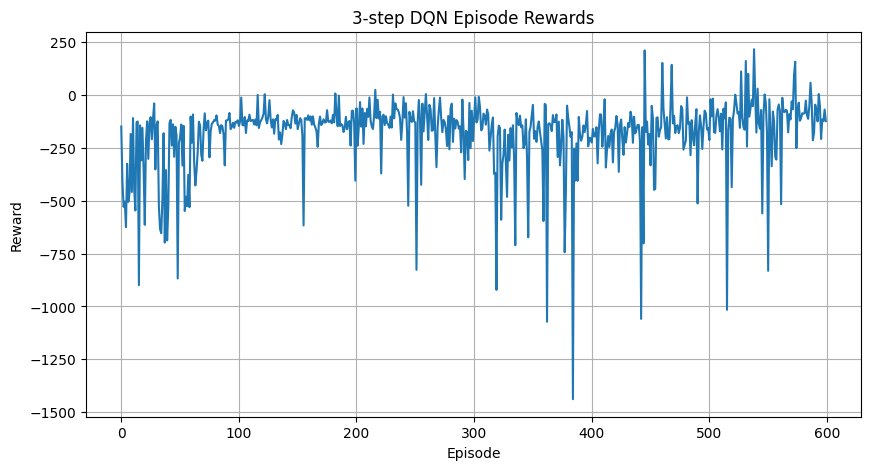

/home/kubwa/anaconda3/envs/RL/lib/python3.11/site-packages/gymnasium/wrappers/rendering.py:293: UserWarning: WARN: Overwriting existing videos at /home/kubwa/02-Deep-RL/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [9]:
# 학습 곡선
plt.figure(figsize=(10, 5))
plt.plot(history)
plt.title(f"{agent.n_steps}-step DQN Episode Rewards")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.grid(True)
plt.show()

# 비디오 저장 및 확인
import glob
import os

agent.save_video("n-step-dqn")

# 가장 최근 비디오 파일 찾기
video_files = glob.glob("videos/*.mp4")
if video_files:
    latest_video = max(video_files, key=os.path.getctime)
    display(display_video(latest_video))
else:
    print("비디오 파일을 찾을 수 없다.")